In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

/Users/sherriii/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sherriii/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [176]:
aq_50 = pd.read_csv('/Users/sherriii/Desktop/sem_2025/ccns/data/aq50_responses.csv')
choice= pd.read_csv('/Users/sherriii/Desktop/sem_2025/ccns/data/choices.csv')
outcome = pd.read_csv('/Users/sherriii/Desktop/sem_2025/ccns/data/outcomes.csv')

In [19]:
aq_50.head()
choice.head()
outcome.head()

,Trial_1,Trial_2,Trial_3,Trial_4,Trial_5,Trial_6,Trial_7,Trial_8,Trial_9,Trial_10,...,Trial_91,Trial_92,Trial_93,Trial_94,Trial_95,Trial_96,Trial_97,Trial_98,Trial_99,Trial_100
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0
3,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,...,1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0
4,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0


In [20]:
aq_50.head()

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,...,Item_41,Item_42,Item_43,Item_44,Item_45,Item_46,Item_47,Item_48,Item_49,Item_50
0,1,0,1,1,1,1,1,1,1,1,...,1,0,1,1,1,0,1,0,1,1
1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,0,1,1,1,1,1,1
2,1,1,1,0,1,1,1,1,1,1,...,0,0,1,1,1,1,0,1,0,0
3,0,1,1,1,1,0,1,0,1,1,...,0,1,1,1,0,1,1,0,1,1
4,1,0,1,1,1,1,0,1,1,1,...,0,1,1,1,0,1,0,1,0,0


In [24]:
subscales_score = {
    'social': [1,11,13,15,22,36,44,45,47,48],
    'attention_switching': [2,4,10,16,25,32,34,37,43,46],
    'attention_detail': [5,6,9,12,19,23,28,29,30,49],
    'communication': [7,17,18,26,27,31,33,35,38,39],
    'imagination': [3,8,14,20,21,24,40,41,42,50]
}

for name, items in subscales_score.items():
    column_names = [f'Item_{i}' for i in items]
    aq_50[name] = aq_50[column_names].sum(axis=1)
    
aq_50['score'] = aq_50.filter(like='Item_').sum(axis=1)

In [28]:
subscales = ['score', 'social', 'attention_switching',
           'attention_detail', 'communication', 'imagination']

asd = aq_50.iloc[:25]
td = aq_50.iloc[25:]

summary_stats = aq_50[subscales].agg(['mean','std','median']).round(3)
summary_asd = asd[subscales].agg(['mean','std','median']).round(3)
summary_td = td[subscales].agg(['mean','std','median']).round(3)

In [30]:
summary_stats

,score,social,attention_switching,attention_detail,communication,imagination
mean,31.340,6.100,6.320,6.320,6.16,6.440
std,5.216,1.581,1.449,1.878,1.91,1.487
median,31.000,6.000,6.000,6.000,6.00,6.500


In [29]:
pd.concat([summary_asd, summary_td], keys=['ASD', 'TD'])

score  social  attention_switching  attention_detail  \
ASD mean    35.000   6.640                7.040             7.280   
    std      4.163   1.411                1.098             1.542   
    median  35.000   7.000                7.000             7.000   
TD  mean    27.680   5.560                5.600             5.360   
    std      3.211   1.583                1.414             1.705   
    median  28.000   5.000                5.000             6.000   

            communication  imagination  
ASD mean            7.040        7.000  
    std             1.567        1.414  
    median          7.000        7.000  
TD  mean            5.280        5.880  
    std             1.838        1.364  
    median          6.000        6.000

In [33]:
td_asd = (td['score'] >= 32).sum()
asd_no_diagnosis = (asd['score'] < 32).sum()
print("TD diagnosed as ASD:", td_asd)
print("ASD missed diagnosis:", asd_no_diagnosis)

TD diagnosed as ASD: 3
ASD missed diagnosis: 5


In [36]:
Y_first = (choice.iloc[:, 0] == 'Y').sum()
Y_first

21

In [42]:
total_smiley_face = (outcome == 1).sum(axis=1)
total_frown_face = (outcome == -1).sum(axis=1)

smiley_asd_mean = total_smiley_face.iloc[:25].mean().round(3)
smiley_td_mean = total_smiley_face.iloc[25:].mean().round(3)
frown_asd_mean = total_frown_face.iloc[:25].mean().round(3)
frown_td_mean = total_frown_face.iloc[25:].mean().round(3)

print(smiley_asd_mean,smiley_td_mean,frown_asd_mean, frown_td_mean)

72.04 73.44 27.96 26.56


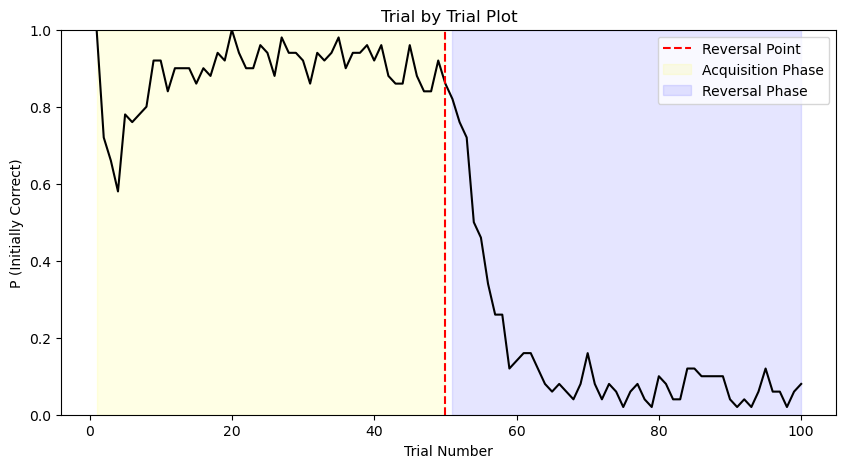

In [53]:
initial_correct = choice.iloc[:, 0]
p_initially_correct = (choice == initial_correct.values[:, None]).mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), p_initially_correct, color='black')
plt.axvline(x=50, linestyle='--', color='red', label='Reversal Point')
plt.fill_between(range(1, 51), 0, 1, color='yellow', alpha=0.1, label='Acquisition Phase')
plt.fill_between(range(51, 101), 0, 1, color='blue', alpha=0.1, label='Reversal Phase')

plt.xlabel('Trial Number')
plt.ylabel('P (Initially Correct)')
plt.title('Trial by Trial Plot')
plt.legend()
plt.ylim(0, 1)
plt.show()

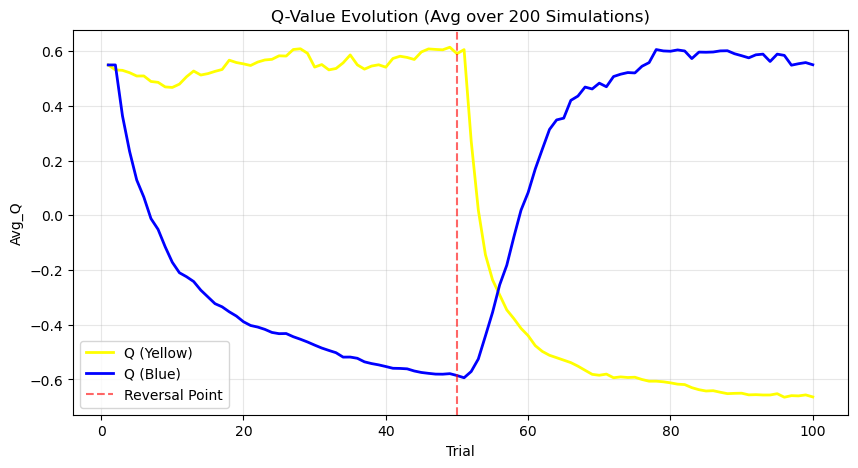

In [84]:
def softmax(Qy, Qb, beta, rng):
    p_y = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
    choice = 'Y' if rng.random() < p_y else 'B'
    return choice, p_y


def simulate_q_learning(alpha, beta, n=100, first_choice='Y', seed=None):
    rng = np.random.default_rng(seed)
    Q = {'Y': 0.55, 'B': 0.55}
    history = []

    for t in range(1, n + 1):
        current_Qy, current_Qb = Q['Y'], Q['B']
        
        if t == 1:
            choice, p_y = first_choice, (1.0 if first_choice == 'Y' else 0.0)
        else:
            choice, p_y = softmax(current_Qy, current_Qb, beta, rng)

        p_y_reward, p_b_reward = get_reward_probs(t, first_choice)
        
        p_success = p_y_reward if choice == 'Y' else p_b_reward
        outcome = 1 if rng.random() < p_success else -1

        prediction_error = outcome - Q[choice]
        Q[choice] += alpha * prediction_error

        history.append({
            'trial': t,
            'choice': choice,
            'outcome': outcome,
            'Qy': current_Qy,
            'Qb': current_Qb,
            'p_yellow': p_y
        })

    return pd.DataFrame(history)

n_sims = 200
all_results = pd.concat([
    simulate_q_learning(0.3, 2.5, seed=s).assign(sim=s) 
    for s in range(n_sims)
])

avg_sim = all_results.groupby('trial')[['Qy', 'Qb']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(avg_sim['trial'], avg_sim['Qy'], label='Q (Yellow)', color='yellow', lw=2)
plt.plot(avg_sim['trial'], avg_sim['Qb'], label='Q (Blue)', color='blue', lw=2)
plt.axvline(50, linestyle='--', color='red', alpha=0.6, label='Reversal Point')

plt.title('Q-Value Evolution (Avg over 200 Simulations)')
plt.xlabel('Trial')
plt.ylabel('Avg_Q')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

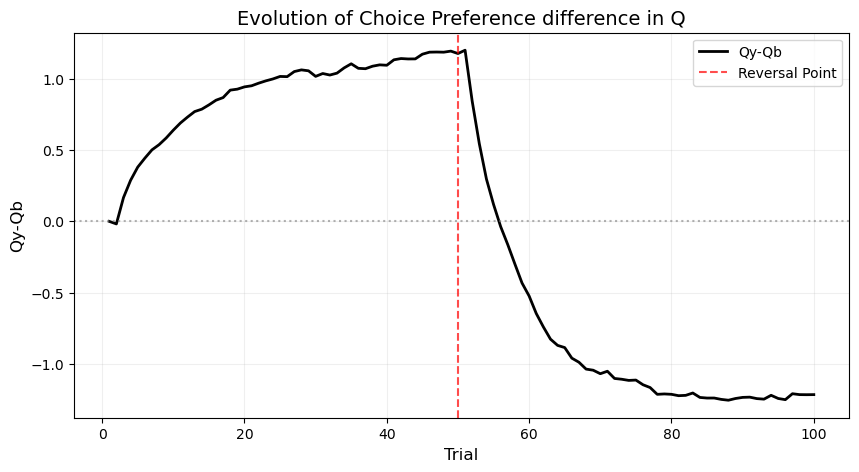

In [242]:
avg_sim['Qdiff'] = avg_sim['Qy'] - avg_sim['Qb']

plt.figure(figsize=(10, 5))
plt.plot(avg_sim['trial'], avg_sim['Qdiff'], color='black', linewidth=2, label='Qy-Qb')

plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
plt.axvline(50, linestyle='--', color='red', alpha=0.7, label='Reversal Point')
plt.title('Evolution of Choice Preference difference in Q', fontsize=14)
plt.xlabel('Trial', fontsize=12)
plt.ylabel('Qy-Qb', fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend()

plt.show()

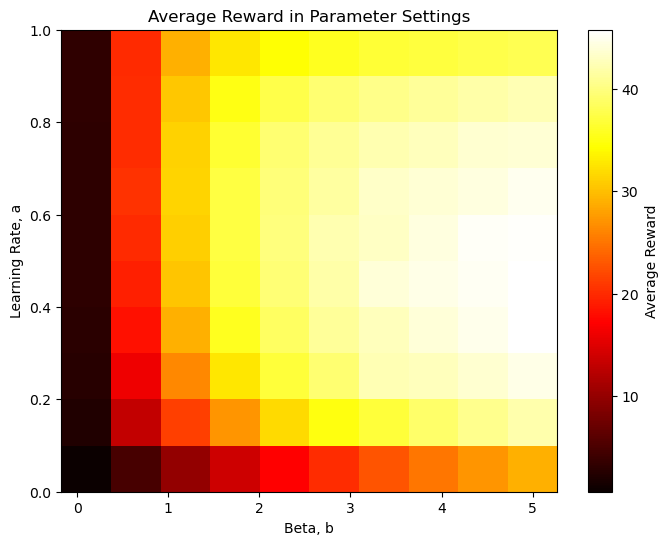

In [264]:
alpha_q3 = np.linspace(0.05, 0.95, 10)
beta_q3 = np.linspace(0.1, 5.0, 10)

avg_rewards = np.zeros((len(alpha_q3), len(beta_q3)))

for i, a in enumerate(alpha_q3):
    for j, b in enumerate(beta_q3):
        sim_rewards = []
        
        for s in range(100):
            df = simulate_q_learning(alpha=a, beta=b, seed=s)
            sim_rewards.append(df['outcome'].sum())
            
        avg_rewards[i, j] = np.mean(sim_rewards)


X, Y = np.meshgrid(beta_q3, alpha_q3)
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, avg_rewards, cmap='hot', shading='auto')

plt.colorbar(label='Average Reward')
plt.xlabel("Beta, b")
plt.ylabel("Learning Rate, a")
plt.title("Average Reward in Parameter Settings")

plt.show()

In [192]:
#alpha_q4 = 0.3
#beta_q4 = 2.5
parameter = [0.3,2.5]

def negative_loglikelihood (parameters, choices, outcomes):
    
    alpha, beta = parameters
    Qy = 0.55
    Qb = 0.55    
    nll = 0
    
    for c in range(len(choices)):
        
        pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
        
        if choices[c] == 'Y':
            prob = pY
            delta = outcomes[c] - Qy
            Qy = Qy + alpha * delta
        else:
            prob = 1 - pY
            delta = outcomes[c] - Qb
            Qb = Qb + alpha * delta
        
        nll -= np.log(prob + 1e-10)
    
    return nll

def get_nll(n, parameter, choice_df, outcome_df):
    choice_ = choice_df.iloc[n].values
    outcome_ = outcome_df.iloc[n].values
    return negative_loglikelihood(parameter, choice_, outcome_)

print(get_nll(9, parameter, choice, outcome).round(3))
print(get_nll(19, parameter, choice, outcome).round(3))

42.137
22.363


In [194]:
pd_q5['nll'].mean()

18.54284201616805

In [266]:
parameter_q5 = [0.3, 2.0]
opt_q5 = []

for i in range(len(choice)):
    opt_nll = minimize(
        negative_loglikelihood,
        x0=parameter_q5,
        args=(choice.iloc[i].values, outcome.iloc[i].values),
        method='Nelder-Mead'
    )
    
    opt_q5.append({
        'index_number': i+1,
        'group': 'ASD' if i < 25 else 'TD',
        'alpha': opt_nll.x[0],
        'beta': opt_nll.x[1],
        'nll' : opt_nll.fun
    })

pd_q5 = pd.DataFrame(opt_q5)
pd_q5.groupby('group')[['alpha', 'beta']].agg(['mean', 'var'])

/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/2401144911.py:14: RuntimeWarning: overflow encountered in exp
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/2401144911.py:14: RuntimeWarning: invalid value encountered in scalar divide
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))


alpha                 beta              
           mean       var       mean           var
group                                             
ASD    0.606945  0.074198  86.880063  42604.888144
TD     0.534756  0.061987  99.682363  49923.718998

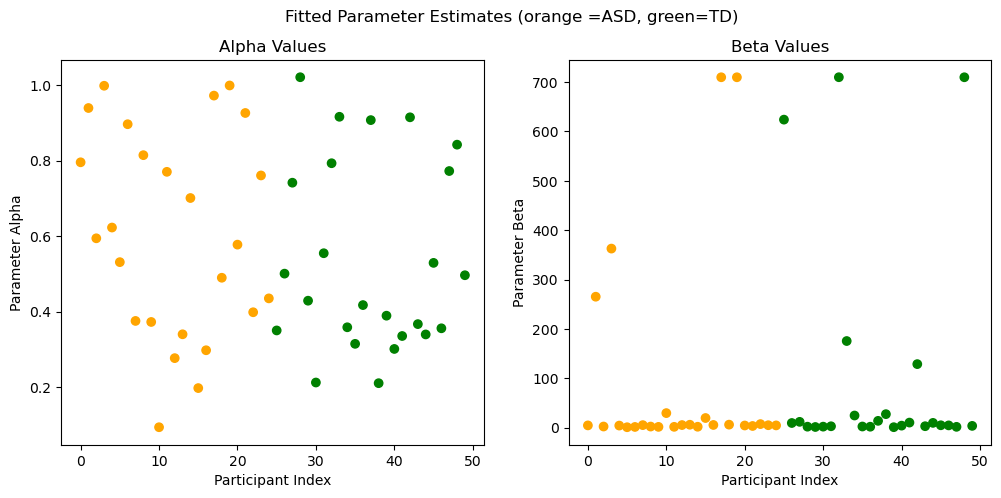

In [143]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(pd_q5['index_number'], pd_q5['alpha'], 
            c=pd_q5['group'].map({'ASD': 'orange', 'TD': 'green'}), label='Alpha')
ax1.set_xlabel('Participant Index')
ax1.set_ylabel('Parameter Alpha')
ax1.set_title('Alpha Values')

ax2.scatter(pd_q5['index_number'], pd_q5['beta'], 
            c=pd_q5['group'].map({'ASD': 'orange', 'TD': 'green'}), label='Beta')
ax2.set_xlabel('Participant Index')
ax2.set_ylabel('Parameter Beta')
ax2.set_title('Beta Values')

# sns.scatterplot(pd_q5, x='index_number', y='alpha', hue='Group')
plt.suptitle('Fitted Parameter Estimates (orange =ASD, green=TD)')
plt.show()

In [153]:
from scipy.stats import pearsonr

corr_, signi_ = pearsonr(pd_q5['alpha'], pd_q5['beta'])

asd_df = pd_q5[pd_q5['group'] == 'ASD']
td_df  = pd_q5[pd_q5['group'] == 'TD']

corr_asd, signi_asd = pearsonr(asd_df['alpha'], asd_df['beta'])
corr_td, signi_td   = pearsonr(td_df['alpha'], td_df['beta'])

print(f"ASD: r = {corr_asd:.3f} (p = {signi_asd:.3f})")
print(f"TD: r = {corr_td:.3f} (p = {signi_td:.3f})")


ASD: r = 0.547 (p = 0.005)
TD: r = 0.292 (p = 0.157)


In [165]:
def sample_parameter_q6(n, mu, cov, seed=42):
    rng = np.random.default_rng(seed)
    
    N = []
    
    while len(N) < n:
        sample = rng.multivariate_normal(mu, cov)
        alpha, beta = sample
        if 0 < alpha < 1 and beta > 0:
            N.append([alpha, beta])
    
    q6_sampled_parameter = pd.DataFrame(N, columns=['alpha', 'beta'])
    return q6_sampled_parameter

mu = [pd_q5['alpha'].mean(), pd_q5['beta'].mean()]
cov = [[0.01, 0],[0, 0.10]]
parameter_q6 = sample_parameter_q6(50, mu, cov)
parameter_q6.head()


,alpha,beta
0,0.466852,93.377573
1,0.664907,93.518526
2,0.440633,92.664241
3,0.539226,93.321640
4,0.485546,93.275900


In [175]:
recovery_q6 = []
N = 50

for iteration in range(1, 6):
    parameter_q6 = sample_parameter_q6(50, mu, cov, seed=42 + iteration)
    q6_alpha = parameter_q6['alpha'].values
    q6_beta = parameter_q6['beta'].values  
    recover_alpha = []
    recover_beta = []
    
    for i in range(N):
        sim_df = simulate_q_learning(
            alpha=q6_alpha[i],
            beta=q6_beta[i],
            n=100,
            seed=i + (iteration * 100)
        )
        
        choice_recover = sim_df['choice'].values
        outcome_recover = sim_df['outcome'].values
        
        fit = minimize(
            negative_loglikelihood,
            x0=[0.3, 2.0],
            args=(choice_recover, outcome_recover),
            method='Nelder-Mead'
        )
        
        recover_alpha.append(fit.x[0])
        recover_beta.append(fit.x[1])

    r_alpha, _ = pearsonr(q6_alpha, recover_alpha)
    r_beta, _ = pearsonr(q6_beta, recover_beta)
    
    recovery_q6.append({
        'int': iteration,
        'alpha_correlation': r_alpha,
        'beta_correlation': r_beta
    })
    
    print(f"int {iteration} complete: alpha r={r_alpha:.3f}, beta r={r_beta:.3f}")

pd.DataFrame(recovery_q6)

/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/758376006.py:14: RuntimeWarning: overflow encountered in exp
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/758376006.py:14: RuntimeWarning: invalid value encountered in scalar divide
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))


int 1 complete: alpha r=0.382, beta r=0.036
int 2 complete: alpha r=0.191, beta r=0.216
int 3 complete: alpha r=0.378, beta r=-0.082
int 4 complete: alpha r=0.462, beta r=0.088
int 5 complete: alpha r=0.154, beta r=-0.153


,int,alpha_correlation,beta_correlation
0,1,0.382216,0.036138
1,2,0.190555,0.216103
2,3,0.378253,-0.082374
3,4,0.461728,0.087902
4,5,0.154201,-0.153040


In [170]:
def simulate_reward_punishment(alpha_rew, alpha_pun, beta, n=100, first_choice='Y', seed=None):
    rng = np.random.default_rng(seed)
    Q = {'Y': 0.55, 'B': 0.55}
    
    history = []

    for x in range(1, n + 1):
        current_Qy, current_Qb = Q['Y'], Q['B']

        if t == 1:
            choice, p_y = first_choice, (1.0 if first_choice == 'Y' else 0.0)
        else:
            choice, p_y = softmax(current_Qy, current_Qb, beta, rng)

        p_y_reward, p_b_reward = get_reward_probs(x, first_choice)

        p_success = p_y_reward if choice == 'Y' else p_b_reward
        outcome = 1 if rng.random() < p_success else -1

        prediction_error = outcome - Q[choice]

        if outcome > 0:
            Q[choice] += alpha_rew * prediction_error
        else:
            Q[choice] += alpha_pun * prediction_error

        history.append({
            'trial': t,
            'choice': choice,
            'outcome': outcome,
            'Qy': current_Qy,
            'Qb': current_Qb,
            'p_yellow': p_y
        })

    return pd.DataFrame(history)

In [171]:
def negative_loglikelihood_rp(parameters, choices, outcomes):
    
    alpha_rew, alpha_pun, beta = parameters
    Qy = 0.55
    Qb = 0.55    
    nll = 0
    
    for c in range(len(choices)):
        
        pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
        
        if choices[c] == 'Y':
            prob = pY
            delta = outcomes[c] - Qy
            
            if outcomes[c] > 0:
                Qy = Qy + alpha_rew * delta
            else:
                Qy = Qy + alpha_pun * delta
                
        else:
            prob = 1 - pY
            delta = outcomes[c] - Qb
            
            if outcomes[c] > 0:
                Qb = Qb + alpha_rew * delta
            else:
                Qb = Qb + alpha_pun * delta
        
        nll -= np.log(prob + 1e-10)
    
    return nll

In [209]:
q7_results = []

for i in range(len(choice)):
    opt_q7 = minimize(
        negative_loglikelihood_rp,
        x0=[0.3, 0.3, 2.0],
        args=(choice.iloc[i].values, outcome.iloc[i].values),
        method='Nelder-Mead'
    )
    
    q7_results.append({
        'index_number': i + 1,
        'group': 'ASD' if i < 25 else 'TD',
        'alpha_rew': opt_q7.x[0],
        'alpha_pun': opt_q7.x[1],
        'beta': opt_q7.x[2],
        'nll_rp': opt_q7.fun,
    })

pd_q7 = pd.DataFrame(q7_results)

/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/1562244253.py:10: RuntimeWarning: overflow encountered in exp
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/1562244253.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))


In [217]:
M1_M2 = pd.merge(
    pd_q5[['index_number', 'group', 'nll']],
    pd_q7[['index_number', 'nll_rp']],
    on='index_number'
)

In [218]:
M1_M2['delta_nll'] = M1_M2['nll'] - M1['nll_rp']
M1_M2.head()

,index_number,group,nll,nll_rp,delta_nll
0,1,ASD,20.797382,20.743385,0.053998
1,2,ASD,8.611283,8.267828,0.343454
2,3,ASD,30.758787,28.828594,1.930193
3,4,ASD,20.072091,20.044206,0.027885
4,5,ASD,12.412491,9.953830,2.458661


In [225]:
k_m1 = 2
k_m2 = 3

M1_M2['AIC_m1'] = 2*k_m1 + 2*M1_M2['nll']
M1_M2['AIC_m2'] = 2*k_m2 + 2*M1_M2['nll_rp']

M1_M2['BIC_m1'] = k_m1 * np.log(100) + 2*M1_M2['nll']
M1_M2['BIC_m2'] = k_m2 * np.log(100) + 2*M1_M2['nll_rp']

aic_percent = (M1_M2['AIC_m2'] < M1_M2['AIC_m1']).mean() * 100
bic_percent = (M1_M2['BIC_m2'] < M1_M2['BIC_m1']).mean() * 100
print(aic_percent)
print(bic_percent)

54.0
36.0


In [238]:
from scipy import stats 
from scipy.stats import ttest_ind
asd_q7 = pd_q7[pd_q7['group'] == 'ASD']
td_q7  = pd_q7[pd_q7['group'] == 'TD']

t_rew, p_rew = ttest_ind(asd_q7['alpha_rew'], td_q7['alpha_rew'])
t_pun, p_pun = ttest_ind(asd_q7['alpha_pun'], td_q7['alpha_pun'])
t_beta, p_beta = ttest_ind(asd_q7['beta'], td_q7['beta'])

In [239]:
def welch_df(x, y):
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)
    n1, n2 = len(x), len(y)
    num = (s1/n1 + s2/n2)**2
    den = (s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1)
    return num / den

In [241]:
df_rew = welch_df(asd_q7['alpha_rew'], td_q7['alpha_rew']).round(3)
df_pun = welch_df(asd_q7['alpha_pun'], td_q7['alpha_pun']).round(3)
df_beta = welch_df(asd_q7['beta'], td_q7['beta']).round(3)
print("alpha_rew: t =", t_rew.round(3), "df =", df_rew, "p =", p_rew.round(3))
print("alpha_pun: t =", t_pun.round(3), "df =", df_pun, "p =", p_pun.round(3))
print("beta: t =", t_beta.round(3), "df =", df_beta, "p =", p_beta.round(3))

alpha_rew: t = 0.917 df = 35.037 p = 0.364
alpha_pun: t = 2.873 df = 44.797 p = 0.006
beta: t = -2.793 df = 28.82 p = 0.007


In [243]:
 # def softmax_prob(Qy, Qb, beta):
   #   z_y = beta * Qy
   #   z_b = beta * Qb
  #    m = max(z_y, z_b)
   #   return np.exp(z_y - m) / (np.exp(z_y - m) + np.exp(z_b - m)) #

def simulate_ewa_dl(rho, phi, beta, n=100, first_choice='Y', seed=None):
    rng = np.random.default_rng(seed)
    
    Q = {'Y': 0.55, 'B': 0.55}
    n_exp = {'Y': 1.0, 'B': 1.0}
    history = []

    for t in range(1, n + 1):
        current_Qy, current_Qb = Q['Y'], Q['B']
        current_nY, current_nB = n_exp['Y'], n_exp['B']
        
        if t == 1:
            choice, p_y = first_choice, (1.0 if first_choice == 'Y' else 0.0)
        else:
            choice, p_y = softmax(current_Qy, current_Qb, beta, rng)

        p_y_reward, p_b_reward = get_reward_probs(t, first_choice)
        
        p_success = p_y_reward if choice == 'Y' else p_b_reward
        outcome = 1 if rng.random() < p_success else -1

        old_n = n_exp[choice]
        old_Q = Q[choice]

        new_n = old_n * rho + 1
        new_Q = (old_Q * phi * old_n + outcome) / new_n

        n_exp[choice] = new_n
        Q[choice] = new_Q

        history.append({
            'trial': t,
            'choice': choice,
            'outcome': outcome,
            'Qy': current_Qy,
            'Qb': current_Qb,
            'nY': current_nY,
            'nB': current_nB,
            'p_yellow': p_y
        })

    return pd.DataFrame(history)


In [244]:
def negative_loglikelihood_ewa(parameters, choices, outcomes):    
    rho, phi, beta = parameters
    Qy = 0.55
    Qb = 0.55
    nY = 1.0
    nB = 1.0
    nll = 0
    
    for c in range(len(choices)):
        
        pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
        
        if choices[c] == 'Y':
            prob = pY
            
            new_nY = nY * rho + 1
            new_Qy = (Qy * phi * nY + outcomes[c]) / new_nY
            
            nY = new_nY
            Qy = new_Qy
            
        else:
            prob = 1 - pY
            
            new_nB = nB * rho + 1
            new_Qb = (Qb * phi * nB + outcomes[c]) / new_nB
            
            nB = new_nB
            Qb = new_Qb
        
        nll -= np.log(prob + 1e-10)
    
    return nll

In [245]:

q9_results = []

for i in range(len(choice)):
    opt_q9 = minimize(
        negative_loglikelihood_ewa,
        x0=[0.3, 0.5, 2.0],
        args=(choice.iloc[i].values, outcome.iloc[i].values),
        method='Nelder-Mead'
    )
    
    q9_results.append({
        'index_number': i + 1,
        'group': 'ASD' if i < 25 else 'TD',
        'rho': opt_q9.x[0],
        'phi': opt_q9.x[1],
        'beta': opt_q9.x[2],
        'nll_ewa': opt_q9.fun
    })

pd_q9 = pd.DataFrame(q9_results)
pd_q9.head()

/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/2153983642.py:12: RuntimeWarning: overflow encountered in exp
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/2153983642.py:12: RuntimeWarning: invalid value encountered in scalar divide
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))


,index_number,group,rho,phi,beta,nll_ewa
0,1,ASD,0.369657,0.196865,6.624506,20.636106
1,2,ASD,0.105565,0.037405,763.871994,8.390062
2,3,ASD,0.756071,0.372769,5.557407,30.320789
3,4,ASD,0.131463,0.001198,802.564237,19.599880
4,5,ASD,0.428610,0.348055,4.828276,12.591126


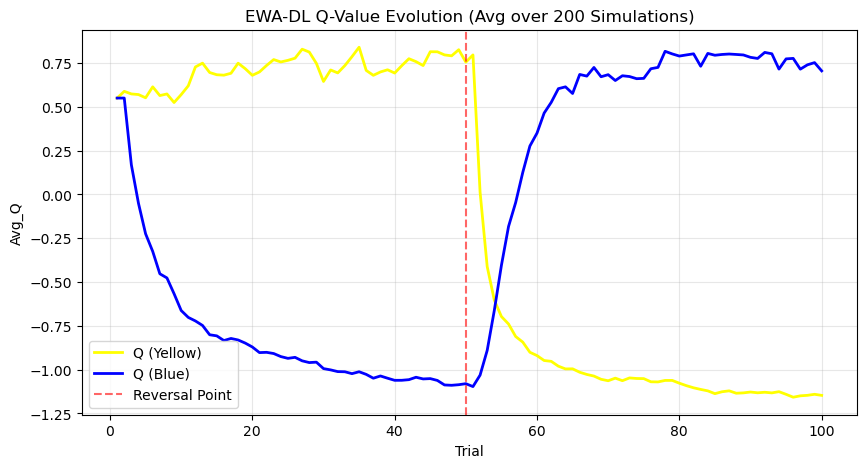

In [246]:
all_results_ewa = pd.concat([
    simulate_ewa_dl(0.3, 0.5, 2.0, seed=s).assign(sim=s)
    for s in range(n_sims)
])

avg_sim_ewa = all_results_ewa.groupby('trial')[['Qy', 'Qb']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(avg_sim_ewa['trial'], avg_sim_ewa['Qy'], label='Q (Yellow)', color='yellow', lw=2)
plt.plot(avg_sim_ewa['trial'], avg_sim_ewa['Qb'], label='Q (Blue)', color='blue', lw=2)
plt.axvline(50, linestyle='--', color='red', alpha=0.6, label='Reversal Point')

plt.title('EWA-DL Q-Value Evolution (Avg over 200 Simulations)')
plt.xlabel('Trial')
plt.ylabel('Avg_Q')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [249]:
pd_q9['AIC_m3'] = 2*3 + 2*pd_q9['nll_ewa']
pd_q9['BIC_m3'] = 3*np.log(100) + 2*pd_q9['nll_ewa']
M2_M3 = pd.merge(
    M1_M2[['index_number','AIC_m2','BIC_m2']],
    pd_q9[['index_number','AIC_m3','BIC_m3']],
    on='index_number'
)


print("Reward-Punishment Model:")
print("Total AIC:", M2_M3['AIC_m2'].sum())
print("Total BIC:", M2_M3['BIC_m2'].sum())

print("\nEWA-DL Model:")
print("Total AIC:", M2_M3['AIC_m3'].sum())
print("Total BIC:", M2_M3['BIC_m3'].sum())

Reward-Punishment Model:
Total AIC: 1950.6218132442787
Total BIC: 2341.3973411424927

EWA-DL Model:
Total AIC: 2003.9616028995122
Total BIC: 2394.737130797726


In [258]:
m3_asd = pd_q9[pd_q9['group']=='ASD']
m3_td  = pd_q9[pd_q9['group']=='TD']

t_rho, p_rho = ttest_ind(m3_asd['rho'], m3_td['rho'])
t_phi, p_phi = ttest_ind(m3_asd['phi'], m3_td['phi'])
t_beta, p_beta = ttest_ind(m3_asd['beta'], m3_td['beta'])

df_rho_m3 = welch_df(m3_asd['rho'], m3_td['rho'])
df_phi_m3 = welch_df(m3_asd['phi'], m3_td['phi'])
df_beta_m3 = welch_df(m3_asd['beta'], m3_td['beta'])

print(f"rho: t = {t_rho:.3f}, df = {df_rho_m3:.2f}, p = {p_rho:.3f}")
print(f"phi: t = {t_phi:.3f}, df = {df_phi_m3:.2f}, p = {p_phi:.3f}")
print(f"beta: t = {t_beta:.3f}, df = {df_beta_m3:.2f}, p = {p_beta:.3f}")

rho: t = 2.359, df = 43.23, p = 0.022
phi: t = -2.074, df = 42.09, p = 0.043
beta: t = 0.302, df = 45.98, p = 0.764


In [ ]:
import seaborn as sns

n_sims = 50 
true_models = ['RP', 'EWA']
fit_models = ['RP', 'EWA']
conf_matrix_aic = np.zeros((2, 2))
conf_matrix_bic = np.zeros((2, 2))

rp_params = [pd_q7['alpha_rew'].mean(), pd_q7['alpha_pun'].mean(), pd_q7['beta'].mean()]
ewa_params = [pd_q9['rho'].mean(), pd_q9['phi'].mean(), pd_q9['beta'].mean()]

for row_idx, gen_model in enumerate(true_models):
    for i in range(n_sims):
        if gen_model == 'RP':
            sim_df = simulate_rp_learning(*rp_params, seed=i)
        else:
            sim_df = simulate_ewa_dl(*ewa_params, seed=i)
            
        choices, outcomes = sim_df['choice'].values, sim_df['outcome'].values
        
        res_rp = minimize(negative_loglikelihood_rp, x0=[0.3, 0.3, 2], args=(choices, outcomes), 
                          method='Nelder-Mead', bounds=[(0,1), (0,1), (0,20)])
        aic_rp = 2*3 + 2*res_rp.fun
        bic_rp = 3*np.log(100) + 2*res_rp.fun
        
        res_ewa = minimize(negative_loglikelihood_ewa, x0=[0.5, 0.5, 2], args=(choices, outcomes), 
                           method='Nelder-Mead', bounds=[(0,1), (0,1), (0,20)])
        aic_ewa = 2*3 + 2*res_ewa.fun
        bic_ewa = 3*np.log(100) + 2*res_ewa.fun
        
        best_aic = 0 if aic_rp < aic_ewa else 1
        best_bic = 0 if bic_rp < bic_ewa else 1
        
        conf_matrix_aic[row_idx, best_aic] += 1
        conf_matrix_bic[row_idx, best_bic] += 1


conf_matrix_aic /= n_sims
conf_matrix_bic /= n_sims

/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/2153983642.py:12: RuntimeWarning: overflow encountered in exp
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/2153983642.py:12: RuntimeWarning: invalid value encountered in scalar divide
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/1562244253.py:10: RuntimeWarning: overflow encountered in exp
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))
/var/folders/10/dp0cb1994dj59zv216gpn8q00000gn/T/ipykernel_44532/1562244253.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pY = np.exp(beta * Qy) / (np.exp(beta * Qy) + np.exp(beta * Qb))


AIC counts:
 Predicted_AIC  EWA  RP
True                  
EWA             32  18
RP              37  13

BIC counts:
 Predicted_BIC  EWA  RP
True                  
EWA             33  17
RP              37  13


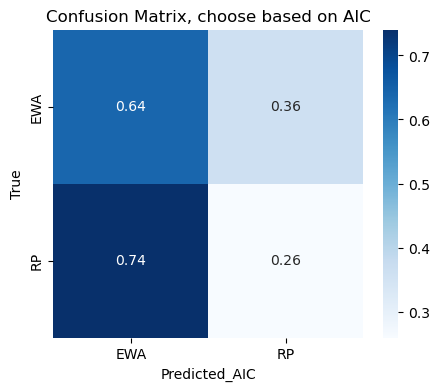

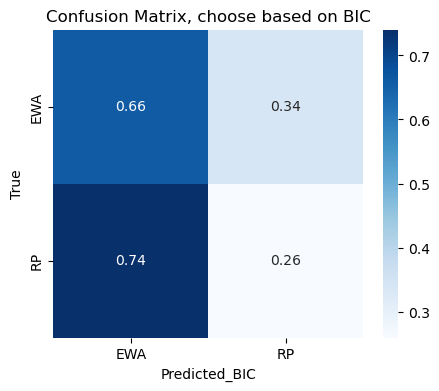

In [263]:
means_rp = [pd_q7['alpha_rew'].mean(), pd_q7['alpha_pun'].mean(), pd_q7['beta'].mean()]
means_ewa = [pd_q9['rho'].mean(), pd_q9['phi'].mean(), pd_q9['beta'].mean()]

results = []

for true_model, params in [('RP', means_rp), ('EWA', means_ewa)]:
    for s in range(50):
        if true_model_name == 'RP':
            sim_df = simulate_reward_punishment(*params, seed=1000 + s)
        else:
            sim_df = simulate_ewa_dl(*params, seed=2000 + s)

        choices = sim_df['choice'].values
        outcomes = sim_df['outcome'].values

        fit_rp = minimize(
            negative_loglikelihood_rp,
            x0=[0.3, 0.3, 2.0],
            args=(choices, outcomes),
            method='Nelder-Mead'
        )

        fit_ewa = minimize(
            negative_loglikelihood_ewa,
            x0=[0.3, 0.5, 2.0],
            args=(choices, outcomes),
            method='Nelder-Mead'
        )

        nll_rp = fit_rp.fun
        nll_ewa = fit_ewa.fun

        k = 3
        n = 100

        aic_rp = 2 * k + 2 * nll_rp
        aic_ewa = 2 * k + 2 * nll_ewa

        bic_rp = k * np.log(n) + 2 * nll_rp
        bic_ewa = k * np.log(n) + 2 * nll_ewa

        winner_aic = 'RP' if aic_rp < aic_ewa else 'EWA'
        winner_bic = 'RP' if bic_rp < bic_ewa else 'EWA'

        results.append({
            'True': true_model,
            'Predicted_AIC': winner_aic,
            'Predicted_BIC': winner_bic
        })

conf_df = pd.DataFrame(results)

cm_aic_counts = pd.crosstab(conf_df['True'], conf_df['Predicted_AIC'])
cm_bic_counts = pd.crosstab(conf_df['True'], conf_df['Predicted_BIC'])

print("AIC counts:\n", cm_aic_counts)
print("\nBIC counts:\n", cm_bic_counts)

cm_aic = pd.crosstab(conf_df['True'], conf_df['Predicted_AIC'], normalize='index')
cm_bic = pd.crosstab(conf_df['True'], conf_df['Predicted_BIC'], normalize='index')

plt.figure(figsize=(5,4))
sns.heatmap(cm_aic, 
            annot=True, 
            cmap='Blues', 
            fmt='.2f')
plt.title('Confusion Matrix, choose based on AIC')
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm_bic, 
            annot=True, 
            cmap='Blues', 
            fmt='.2f')
plt.title('Confusion Matrix, choose based on BIC')
plt.show()